## Preliminary experiment: IID Gaussian noise

Before introducing temporally correlated perturbations, we first tested
the synthetic classification task under independently sampled Gaussian
noise.

For each trajectory value, noise was added independently as

$$
\tilde{x}_{t,c}
=
x_{t,c}
+
\sigma \epsilon_{t,c},
\qquad
\epsilon_{t,c} \sim \mathcal{N}(0,1).
$$

Because the perturbation is sampled independently for every time point
and channel, it does not introduce persistent temporal drift.

The purpose of this preliminary probe was to determine whether increasing
measurement noise alone was sufficient to challenge the CTM.

In [34]:
import pandas as pd

iid_results = pd.DataFrame({
    "noise_std": [0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0],
    "val_accuracy": [1.000, 1.000, 1.000, 1.000, 1.000, 1.000, 0.988],
    "mean_most_certain_tick": [25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 24.9],
})

iid_results

,noise_std,val_accuracy,mean_most_certain_tick
0,0.05,1.000,25.0
1,0.10,1.000,25.0
2,0.25,1.000,25.0
3,0.50,1.000,25.0
4,1.00,1.000,25.0
5,2.00,1.000,25.0
6,4.00,0.988,24.9


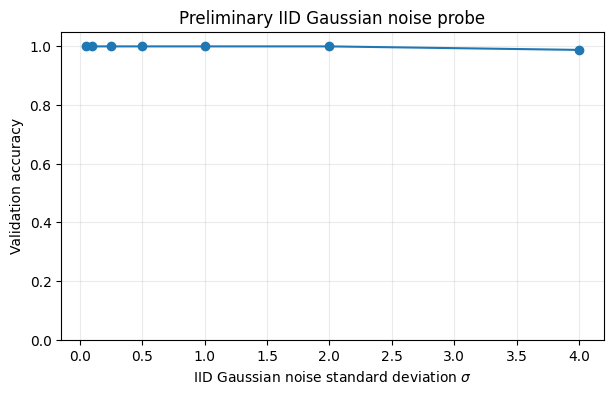

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(
    iid_results["noise_std"],
    iid_results["val_accuracy"],
    marker="o",
)

plt.xlabel(r"IID Gaussian noise standard deviation $\sigma$")
plt.ylabel("Validation accuracy")
plt.title("Preliminary IID Gaussian noise probe")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)

plt.show()

### Preliminary observation

Validation accuracy remained essentially saturated across the entire
IID Gaussian noise sweep. Accuracy stayed at 1.000 from
$\sigma=0.05$ through $\sigma=2.0$, and decreased only slightly to
0.988 at $\sigma=4.0$.

The mean most-certain internal tick also remained approximately unchanged
at 25.

This probe therefore did not reveal a useful transition from easy to
difficult classification. One possible explanation is that independent
frame-wise noise perturbs individual observations without consistently
altering the temporal direction of the underlying trajectory.

This motivated the next experiment, in which noise is accumulated over
time using a Wiener process. The resulting perturbations are temporally
correlated and can produce persistent trajectory drift.

## Experiment 1: Temporally Correlated Wiener Noise

We define a Wiener process by

$$
W_0 = 0
$$

$$
W_t = W_{t-1} + \sqrt{\Delta t}\,\epsilon_t,
\qquad
\epsilon_t \sim \mathcal{N}(0,1)
$$

and perturb each channel of the clean trajectory as

$$
\tilde{x}_{t,c}
=
x_{t,c}
+
\sigma_W W_{t,c}.
$$

### Visual sanity check

Before training the CTM, we inspect how temporally correlated
noise modifies the synthetic trajectories. Unlike IID Gaussian
noise, Wiener perturbations accumulate over time, producing
persistent drift in the observed signal.

In [22]:
import importlib
import synthetic_data

importlib.reload(synthetic_data)

from synthetic_data import add_wiener_noise

import inspect
print(inspect.signature(add_wiener_noise))

(x, sigma, rng=None, time_axis=-1)


In [23]:
import numpy as np
import matplotlib.pyplot as plt

from synthetic_data import make_synthetic_grasps, add_wiener_noise

# Generate the same synthetic dataset used by the baseline
X, y = make_synthetic_grasps()

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

# Take ONE movement trajectory

# x_clean = X[0].numpy()

#X[0] is not perfectluy noise-free. 
X_clean, y = make_synthetic_grasps(
    noise_std=0.0,
    seed=0,
)

x_clean = X_clean[0].numpy()

print("Dataset:", X_clean.shape)
print("One trajectory shape:", x_clean.shape)
print("Class:", y[0].item())

Dataset shape: torch.Size([1600, 15, 100])
Labels shape: torch.Size([1600])
Dataset: torch.Size([1600, 15, 100])
One trajectory shape: (15, 100)
Class: 0


In [24]:
rng = np.random.default_rng(42)

x_test = add_wiener_noise(
    x_clean,
    sigma=0.5,
    rng=rng,
)

print("clean shape:", x_clean.shape)
print("noisy shape:", x_test.shape)

print(
    "Initial timestep unchanged:",
    np.allclose(x_clean[:, 0], x_test[:, 0])
)

clean shape: (15, 100)
noisy shape: (15, 100)
Initial timestep unchanged: True


In [25]:
import inspect

print(inspect.signature(add_wiener_noise))

(x, sigma, rng=None, time_axis=-1)


First visualization

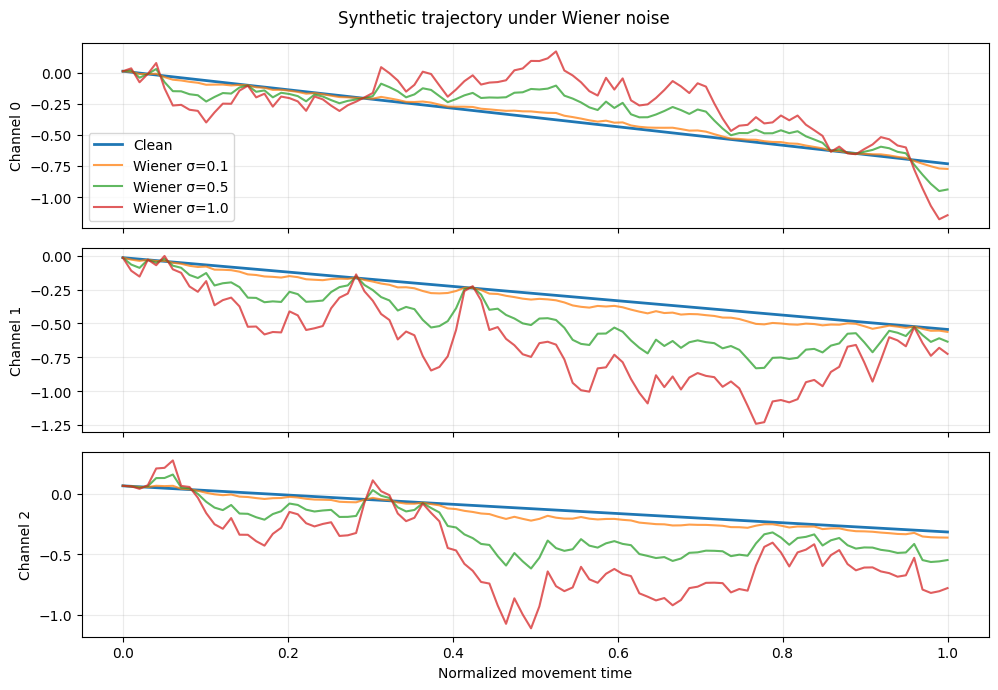

In [26]:
sigmas = [0.1, 0.5, 1.0]
channels = [0, 1, 2]

time = np.linspace(0, 1, x_clean.shape[-1])

fig, axes = plt.subplots(
    len(channels),
    1,
    figsize=(10, 7),
    sharex=True,
)

for ax, channel in zip(axes, channels):

    # Original clean trajectory
    ax.plot(
        time,
        x_clean[channel, :],
        linewidth=2,
        label="Clean",
    )

    # Same Wiener realization, scaled by different sigma values
    for sigma in sigmas:

        rng = np.random.default_rng(42)

        x_noisy = add_wiener_noise(
            x_clean,
            sigma=sigma,
            rng=rng,
        )

        ax.plot(
            time,
            x_noisy[channel, :],
            alpha=0.75,
            label=f"Wiener σ={sigma}",
        )

    ax.set_ylabel(f"Channel {channel}")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Normalized movement time")
axes[0].legend()

fig.suptitle(
    "Synthetic trajectory under Wiener noise"
)

plt.tight_layout()
plt.show()

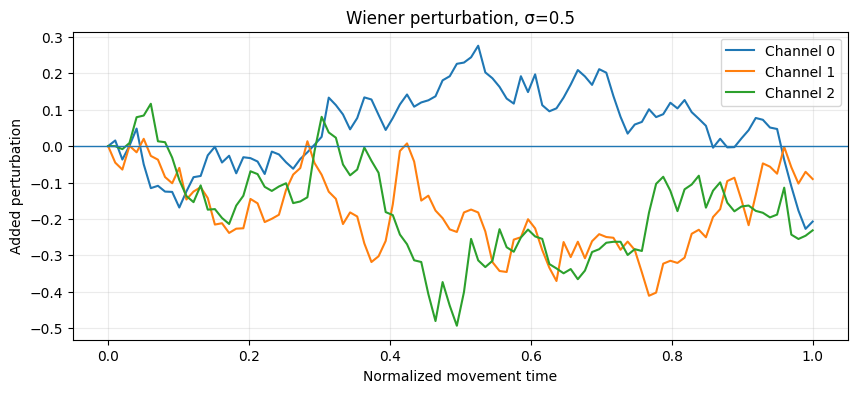

In [27]:
sigma = 0.5

rng = np.random.default_rng(42)

x_noisy = add_wiener_noise(
    x_clean,
    sigma=sigma,
    rng=rng,
)

wiener_perturbation = x_noisy - x_clean

plt.figure(figsize=(10, 4))

for channel in [0, 1, 2]:
    plt.plot(
        time,
        wiener_perturbation[channel, :],
        label=f"Channel {channel}",
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Normalized movement time")
plt.ylabel("Added perturbation")
plt.title(f"Wiener perturbation, σ={sigma}")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

### Visual sanity check

Unlike independently sampled Gaussian noise, the Wiener perturbation
does not fluctuate independently between successive observations.
Instead, random increments accumulate over time, causing persistent
trajectory drift. The strength of this drift increases with
$\sigma_W$, while all trajectories originate from the same initial
state because $W_0 = 0$.

This experiment therefore introduces temporally structured uncertainty
while preserving the underlying target-directed synthetic movement.

In [29]:
import importlib
import experiment_runner

importlib.reload(experiment_runner)

from experiment_runner import ExperimentConfig, run_experiment
from dataclasses import replace

base_config = ExperimentConfig(
    experiment_name="wiener_pilot",
    data_seed=0,
    split_seed=0,
    run_seed=0,
    noise_std=0.0,
    wiener_sigma=0.0,
    full_timesteps=100,
    window_start=0,
    window_length=None,
    epochs=15,
    evaluate_test=False,
)

In [30]:
wiener_sigmas = [0.0, 0.1, 0.5, 1.0, 2.0]

pilot_results = []

for sigma in wiener_sigmas:
    print("\n" + "=" * 60)
    print(f"Wiener sigma = {sigma}")
    print("=" * 60)

    config = replace(
        base_config,
        experiment_name=f"wiener_pilot_sigma_{sigma}",
        wiener_sigma=sigma,
    )

    result = run_experiment(config)

    pilot_results.append(result)


Wiener sigma = 0.0
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
epoch 01 | train loss 1.7390 | train acc 0.409 | val loss 0.8786 | val acc 1.000
epoch 02 | train loss 0.2241 | train acc 1.000 | val loss 0.0036 | val acc 1.000
epoch 03 | train loss 0.0013 | train acc 1.000 | val loss 0.0006 | val acc 1.000
epoch 04 | train loss 0.0005 | train acc 1.000 | val loss 0.0004 | val acc 1.000
epoch 05 | train loss 0.0003 | train acc 1.000 | val loss 0.0003 | val acc 1.000
epoch 06 | train loss 0.0002 | train acc 1.000 | val loss 0.0002 | val acc 1.000
epoch 07 | train loss 0.0002 | train acc 1.000 | val loss 0.0002 | val acc 1.000
epoch 08 | train loss 0.0002 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 09 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 10 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 11 | train loss 0.0001 | train acc 1.000 | val loss 

In [31]:
import pandas as pd

wiener_summary = pd.DataFrame({
    "wiener_sigma": [0.0, 0.1, 0.5, 1.0, 2.0],
    "train_accuracy": [1.000, 1.000, 1.000, 0.954, 0.635],
    "val_accuracy": [1.000, 1.000, 0.992, 0.892, 0.425],
})

wiener_summary

,wiener_sigma,train_accuracy,val_accuracy
0,0.0,1.000,1.000
1,0.1,1.000,1.000
2,0.5,1.000,0.992
3,1.0,0.954,0.892
4,2.0,0.635,0.425


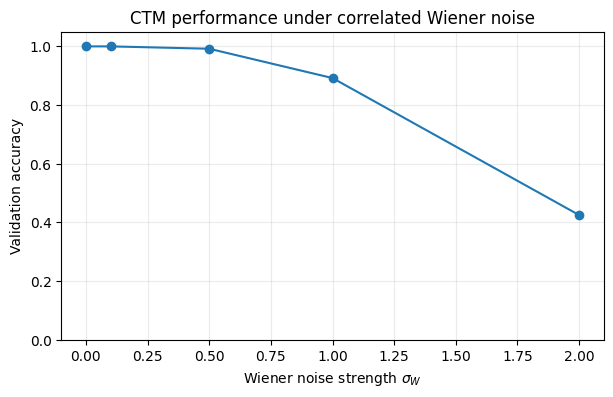

In [32]:
plt.figure(figsize=(7, 4))

plt.plot(
    wiener_summary["wiener_sigma"],
    wiener_summary["val_accuracy"],
    marker="o",
)

plt.xlabel(r"Wiener noise strength $\sigma_W$")
plt.ylabel("Validation accuracy")
plt.title("CTM performance under correlated Wiener noise")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)

plt.show()

### Preliminary observation

Performance remained saturated for weak correlated noise
($\sigma_W \leq 0.1$) and remained close to perfect at
$\sigma_W = 0.5$. A clear reduction in validation accuracy
appeared at $\sigma_W = 1.0$, followed by substantial
degradation at $\sigma_W = 2.0$.

The pilot therefore places the transition from an easily
learnable to a substantially more difficult regime approximately
between $\sigma_W = 0.5$ and $\sigma_W = 1.0$.

These results are based on a single seed and should be treated
as preliminary. A later experiment should sample the transition
region more densely and evaluate variability across multiple seeds.

## Experiment 2: Partial Observation Windows

### Question

How much of the beginning of the synthetic movement is required
for the CTM to identify the target class?

The full synthetic trajectory contains 100 external time steps.
We progressively shorten the observation window while keeping its
starting position fixed at movement onset.

### Experiment 2A: Amount of early movement available

We first keep the observation window anchored at movement onset and
progressively reduce its duration.

The tested window lengths are

$$
T_{\mathrm{obs}} \in \{100, 75, 50, 25, 10\}.
$$

Thus, a window length of 25 contains only the first quarter of the
movement, while a window length of 10 contains only the first 10% of
the trajectory.

All other experimental settings are held fixed.

In [36]:
from dataclasses import replace
from experiment_runner import ExperimentConfig, run_experiment

window_base_config = ExperimentConfig(
    experiment_name="window_prefix",
    data_seed=0,
    split_seed=0,
    run_seed=0,

    # Original synthetic baseline condition
    noise_std=0.05,
    wiener_sigma=0.0,

    full_timesteps=100,

    # Changed below during the sweep
    window_start=0,
    window_length=None,

    epochs=15,
    evaluate_test=False,
)

In [37]:
window_lengths = [100, 75, 50, 25, 10]

window_results = []

for length in window_lengths:

    print("\n" + "=" * 60)
    print(f"Prefix window length = {length}")
    print("=" * 60)

    config = replace(
        window_base_config,
        experiment_name=f"prefix_window_{length}",
        window_start=0,
        window_length=length,
    )

    result = run_experiment(config)

    window_results.append(result)


Prefix window length = 100
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
epoch 01 | train loss 1.7399 | train acc 0.409 | val loss 0.8827 | val acc 1.000
epoch 02 | train loss 0.2261 | train acc 1.000 | val loss 0.0037 | val acc 1.000
epoch 03 | train loss 0.0014 | train acc 1.000 | val loss 0.0006 | val acc 1.000
epoch 04 | train loss 0.0005 | train acc 1.000 | val loss 0.0004 | val acc 1.000
epoch 05 | train loss 0.0003 | train acc 1.000 | val loss 0.0003 | val acc 1.000
epoch 06 | train loss 0.0002 | train acc 1.000 | val loss 0.0002 | val acc 1.000
epoch 07 | train loss 0.0002 | train acc 1.000 | val loss 0.0002 | val acc 1.000
epoch 08 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 09 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 10 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 11 | train loss 0.0001 | train acc 1.000 | v

In [42]:
window_summary = pd.DataFrame({
    "window_length": [100, 75, 50, 25, 10],
    "movement_observed_pct": [100, 75, 50, 25, 10],
    "epoch_1_val_accuracy": [1.000, 1.000, 0.825, 0.808, 0.225],
    "final_val_accuracy": [1.000, 1.000, 1.000, 1.000, 1.000],
})

window_summary

,window_length,movement_observed_pct,epoch_1_val_accuracy,final_val_accuracy
0,100,100,1.000,1.0
1,75,75,1.000,1.0
2,50,50,0.825,1.0
3,25,25,0.808,1.0
4,10,10,0.225,1.0


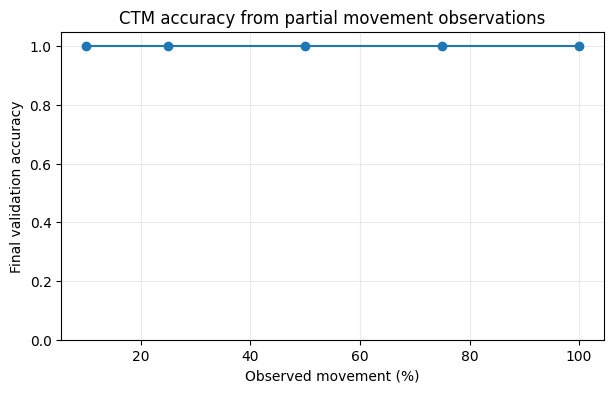

In [43]:
plot_df = window_summary.sort_values("movement_observed_pct")

plt.figure(figsize=(7, 4))

plt.plot(
    plot_df["movement_observed_pct"],
    plot_df["final_val_accuracy"],
    marker="o",
)

plt.xlabel("Observed movement (%)")
plt.ylabel("Final validation accuracy")
plt.title("CTM accuracy from partial movement observations")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)

plt.show()

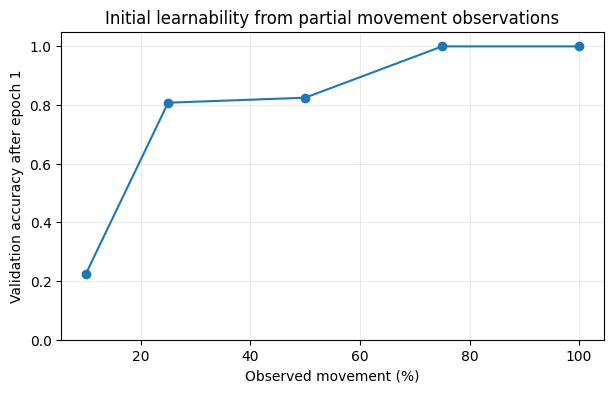

In [44]:
plt.figure(figsize=(7, 4))

plt.plot(
    plot_df["movement_observed_pct"],
    plot_df["epoch_1_val_accuracy"],
    marker="o",
)

plt.xlabel("Observed movement (%)")
plt.ylabel("Validation accuracy after epoch 1")
plt.title("Initial learnability from partial movement observations")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)

plt.show()

### Preliminary observation

Final validation accuracy reached 1.000 for all tested prefix-window
lengths, including trajectories restricted to only the first 10% of
the movement.

However, shorter windows substantially reduced early training
performance. With the full trajectory and the first 75% of the
trajectory, validation accuracy was already 1.000 after the first
epoch. In contrast, the 10-step condition achieved only 0.225
validation accuracy after the first epoch, although it subsequently
reached 1.000.

These results suggest that class-specific information is already
present very early in the current synthetic trajectories. Reducing
the observation duration makes the task harder to learn, but does not
prevent eventual perfect classification.

This may indicate that the synthetic data generator produces
class-separable trajectory directions from very early movement stages.

### Experiment 2B: Effect of temporal window position

The previous experiment showed that the CTM can eventually learn the
classification task even from a short prefix of the synthetic movement.

We now ask a different question:

> Does the location of the observed segment within the movement matter?

To isolate temporal position from the amount of available information,
we use a fixed window length of 25 time steps and compare three phases:

- **Beginning:** time steps 0–24
- **Middle:** time steps 37–61
- **End:** time steps 75–99

Thus, every model receives exactly 25 observations, but from a different
stage of the movement.

All other experimental parameters are held fixed.

In [45]:
window_positions = {
    "beginning": 0,
    "middle": 37,
    "end": 75,
}

position_results = []

for position, start in window_positions.items():

    print("\n" + "=" * 60)
    print(f"Window position = {position} | start = {start} | length = 25")
    print("=" * 60)

    config = replace(
        window_base_config,
        experiment_name=f"window25_{position}",
        window_start=start,
        window_length=25,
    )

    result = run_experiment(config)

    position_results.append({
        "position": position,
        "window_start": start,
        "result": result,
    })


Window position = beginning | start = 0 | length = 25
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
epoch 01 | train loss 1.8611 | train acc 0.330 | val loss 1.1427 | val acc 0.808
epoch 02 | train loss 0.3931 | train acc 0.935 | val loss 0.0118 | val acc 1.000
epoch 03 | train loss 0.0031 | train acc 1.000 | val loss 0.0008 | val acc 1.000
epoch 04 | train loss 0.0006 | train acc 1.000 | val loss 0.0005 | val acc 1.000
epoch 05 | train loss 0.0004 | train acc 1.000 | val loss 0.0003 | val acc 1.000
epoch 06 | train loss 0.0003 | train acc 1.000 | val loss 0.0003 | val acc 1.000
epoch 07 | train loss 0.0002 | train acc 1.000 | val loss 0.0002 | val acc 1.000
epoch 08 | train loss 0.0002 | train acc 1.000 | val loss 0.0002 | val acc 1.000
epoch 09 | train loss 0.0002 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 10 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 11 | train loss 0

In [47]:
position_summary = pd.DataFrame({
    "position": ["Beginning", "Middle", "End"],
    "window_start": [0, 37, 75],
    "window_length": [25, 25, 25],
    "epoch_1_val_accuracy": [0.808, 0.875, 0.875],
    "final_val_accuracy": [1.000, 1.000, 1.000],
})

position_summary

,position,window_start,window_length,epoch_1_val_accuracy,final_val_accuracy
0,Beginning,0,25,0.808,1.0
1,Middle,37,25,0.875,1.0
2,End,75,25,0.875,1.0


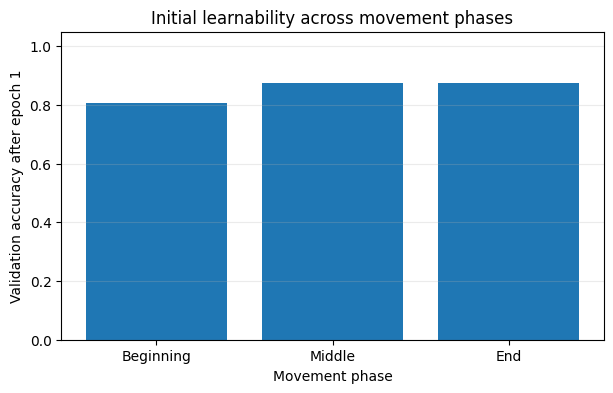

In [48]:
plt.figure(figsize=(7, 4))

plt.bar(
    position_summary["position"],
    position_summary["epoch_1_val_accuracy"],
)

plt.ylabel("Validation accuracy after epoch 1")
plt.xlabel("Movement phase")
plt.title("Initial learnability across movement phases")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.25)

plt.show()

### Preliminary observation

With the observation duration fixed at 25 time steps, models trained
on the beginning, middle, and end of the movement all eventually
reached perfect validation accuracy.

The beginning window was somewhat harder during the first training
epoch, reaching 0.808 validation accuracy compared with 0.875 for
both the middle and end windows. However, all three conditions reached
1.000 validation accuracy by the second epoch.

Together with Experiment 2A, these findings indicate that the current
synthetic trajectories contain highly class-separable information
throughout most of the movement. Even a relatively short temporal
segment is sufficient for eventual perfect classification.

The current experiment therefore does not provide evidence that later
movement phases are necessary for identifying the target class.

In [50]:
ExperimentConfig.__dataclass_fields__.keys()

dict_keys(['experiment_name', 'data_seed', 'split_seed', 'run_seed', 'n_per_class', 'n_classes', 'n_channels', 'full_timesteps', 'noise_std', 'wiener_sigma', 'window_start', 'window_length', 'train_fraction', 'val_fraction', 'batch_size', 'iterations', 'd_model', 'd_input', 'heads', 'n_synch_out', 'n_synch_action', 'synapse_depth', 'memory_length', 'deep_nlms', 'memory_hidden_dims', 'do_layernorm_nlm', 'dropout', 'neuron_select_type', 'n_random_pairing_self', 'learning_rate', 'weight_decay', 'epochs', 'device', 'evaluate_test'])

In [51]:
print("Current baseline internal ticks:", window_base_config.iterations)

Current baseline internal ticks: 25


## Experiment 3: Internal Computation Time

### Question

How much internal computation does the CTM require to solve the
synthetic grasp-classification task?

Unlike the observation-window experiments, the external input is kept
unchanged. Every model receives the complete 100-step trajectory.

Instead, we vary the maximum number of CTM internal ticks:

$$
T_{\mathrm{internal}} \in \{5, 10, 25, 50\}.
$$

An internal tick represents one recurrent step of CTM computation and
is distinct from the 100 external time steps of the input trajectory.

All other model, data, and training parameters are held fixed.

In [52]:
tick_base_config = replace(
    window_base_config,

    experiment_name="internal_ticks",

    noise_std=0.05,
    wiener_sigma=0.0,

    full_timesteps=100,
    window_start=0,
    window_length=None,
)

In [53]:
tick_values = [5, 10, 25, 50]

tick_results = []

for ticks in tick_values:

    print("\n" + "=" * 60)
    print(f"Internal ticks = {ticks}")
    print("=" * 60)

    config = replace(
        tick_base_config,
        experiment_name=f"internal_ticks_{ticks}",
        iterations=ticks,
    )

    result = run_experiment(config)

    tick_results.append({
        "internal_ticks": ticks,
        "result": result,
    })


Internal ticks = 5
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
epoch 01 | train loss 2.0675 | train acc 0.177 | val loss 2.0086 | val acc 0.375
epoch 02 | train loss 1.6913 | train acc 0.489 | val loss 1.1592 | val acc 0.625
epoch 03 | train loss 0.7100 | train acc 0.704 | val loss 0.3923 | val acc 0.875
epoch 04 | train loss 0.1543 | train acc 0.982 | val loss 0.0266 | val acc 1.000
epoch 05 | train loss 0.0121 | train acc 1.000 | val loss 0.0052 | val acc 1.000
epoch 06 | train loss 0.0036 | train acc 1.000 | val loss 0.0026 | val acc 1.000
epoch 07 | train loss 0.0021 | train acc 1.000 | val loss 0.0017 | val acc 1.000
epoch 08 | train loss 0.0014 | train acc 1.000 | val loss 0.0012 | val acc 1.000
epoch 09 | train loss 0.0011 | train acc 1.000 | val loss 0.0009 | val acc 1.000
epoch 10 | train loss 0.0008 | train acc 1.000 | val loss 0.0007 | val acc 1.000
epoch 11 | train loss 0.0007 | train acc 1.000 | val loss 

In [54]:
tick_results[0]["result"].keys()

dict_keys(['run_id', 'config_hash', 'experiment_name', 'data_seed', 'split_seed', 'run_seed', 'n_per_class', 'n_classes', 'n_channels', 'full_timesteps', 'noise_std', 'wiener_sigma', 'window_start', 'window_length', 'train_fraction', 'val_fraction', 'batch_size', 'iterations', 'd_model', 'd_input', 'heads', 'n_synch_out', 'n_synch_action', 'synapse_depth', 'memory_length', 'deep_nlms', 'memory_hidden_dims', 'do_layernorm_nlm', 'dropout', 'neuron_select_type', 'n_random_pairing_self', 'learning_rate', 'weight_decay', 'epochs', 'device', 'evaluate_test', 'n_train', 'n_val', 'n_test', 'effective_timesteps', 'device_used', 'parameter_count', 'best_epoch', 'runtime_seconds', 'train_loss', 'train_accuracy_most_certain', 'train_accuracy_final_tick', 'val_loss', 'val_accuracy_most_certain', 'val_accuracy_final_tick', 'val_mean_most_certain_tick', 'val_mean_selected_certainty', 'test_loss', 'test_accuracy_most_certain', 'test_accuracy_final_tick', 'status'])

In [55]:
import pandas as pd

tick_summary = pd.DataFrame({
    "internal_ticks": [
        item["internal_ticks"]
        for item in tick_results
    ],

    "val_accuracy_most_certain": [
        item["result"]["val_accuracy_most_certain"]
        for item in tick_results
    ],

    "val_accuracy_final_tick": [
        item["result"]["val_accuracy_final_tick"]
        for item in tick_results
    ],

    "mean_most_certain_tick": [
        item["result"]["val_mean_most_certain_tick"]
        for item in tick_results
    ],

    "mean_selected_certainty": [
        item["result"]["val_mean_selected_certainty"]
        for item in tick_results
    ],

    "best_epoch": [
        item["result"]["best_epoch"]
        for item in tick_results
    ],

    "runtime_seconds": [
        item["result"]["runtime_seconds"]
        for item in tick_results
    ],
})

tick_summary

,internal_ticks,val_accuracy_most_certain,val_accuracy_final_tick,mean_most_certain_tick,mean_selected_certainty,best_epoch,runtime_seconds
0,5,1.0,1.0,5.0,0.998582,15,7.309697
1,10,1.0,1.0,10.0,0.999565,15,12.254442
2,25,1.0,1.0,25.0,0.999752,15,28.051655
3,50,1.0,1.0,50.0,0.999840,15,53.765779


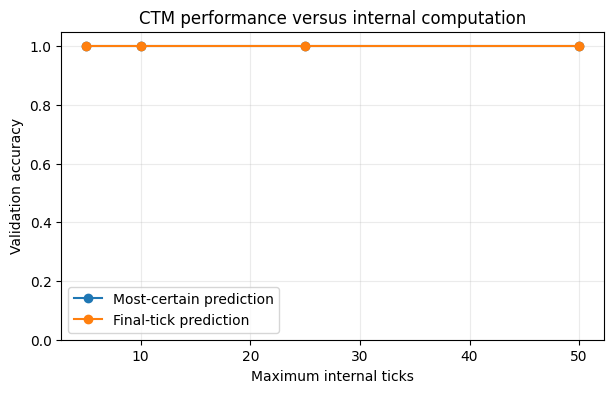

In [56]:
plt.figure(figsize=(7, 4))

plt.plot(
    tick_summary["internal_ticks"],
    tick_summary["val_accuracy_most_certain"],
    marker="o",
    label="Most-certain prediction",
)

plt.plot(
    tick_summary["internal_ticks"],
    tick_summary["val_accuracy_final_tick"],
    marker="o",
    label="Final-tick prediction",
)

plt.xlabel("Maximum internal ticks")
plt.ylabel("Validation accuracy")
plt.title("CTM performance versus internal computation")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend()

plt.show()

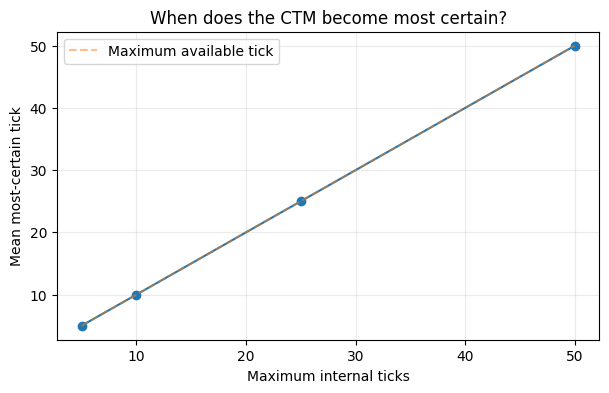

In [57]:
plt.figure(figsize=(7, 4))

plt.plot(
    tick_summary["internal_ticks"],
    tick_summary["mean_most_certain_tick"],
    marker="o",
)

plt.plot(
    tick_summary["internal_ticks"],
    tick_summary["internal_ticks"],
    linestyle="--",
    alpha=0.5,
    label="Maximum available tick",
)

plt.xlabel("Maximum internal ticks")
plt.ylabel("Mean most-certain tick")
plt.title("When does the CTM become most certain?")
plt.grid(alpha=0.25)
plt.legend()

plt.show()

### Preliminary observation

All tested internal-computation budgets eventually achieved perfect
validation accuracy, including the model restricted to only five
internal ticks. However, models with larger tick budgets learned the
task considerably faster during training.

A second pattern emerged in the certainty dynamics. For every tested
configuration, the mean most-certain tick coincided with the maximum
number of internal ticks available to the model. Thus, models allowed
5, 10, 25, and 50 internal ticks were maximally certain at
approximately ticks 5, 10, 25, and 50, respectively.

This indicates that classification accuracy and certainty dynamics
behave differently. Correct classification can be achieved with a
small computational budget, while the model continues to increase its
certainty as additional internal computation becomes available.

However, because a separate model was trained for each tick budget,
this experiment does not establish that additional ticks are necessary
at inference time. The boundary-aligned certainty could reflect
continued representational refinement, or a general tendency for
certainty to increase over recurrent processing.

A useful follow-up would therefore examine the complete accuracy and
certainty trajectories across internal ticks within a single model
trained with a large computational budget.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import replace

import importlib
import experiment_runner

importlib.reload(experiment_runner)

from experiment_runner import ExperimentConfig, run_experiment

/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
sliding_base_config = ExperimentConfig(
    experiment_name="sliding_window",
    data_seed=0,
    split_seed=0,
    run_seed=0,

    noise_std=0.05,
    wiener_sigma=0.0,

    full_timesteps=100,
    window_start=0,
    window_length=None,

    epochs=15,
    evaluate_test=False,
)

# Experiment 4: Sliding Observation Windows

## Question

How does classification performance depend jointly on the size and
temporal position of the observed movement segment?

Previous experiments varied either window length while keeping the
window anchored at movement onset, or compared a small number of
fixed temporal positions.

Here, observation windows are systematically moved across the full
100-step synthetic trajectory.

We test window lengths

$$
L \in \{10, 25, 50\}
$$

and slide each window across the movement in approximately 10-step
increments.

For each condition, a separate CTM is trained and evaluated using
only the selected temporal segment. All other experimental settings
are held fixed.

In [5]:
window_sizes = [10, 25, 50]
step = 10

window_conditions = []

for length in window_sizes:

    starts = list(
        range(
            0,
            100 - length + 1,
            step,
        )
    )

    # Make sure the final valid position is represented.
    final_start = 100 - length

    if final_start not in starts:
        starts.append(final_start)

    for start in starts:
        window_conditions.append(
            {
                "window_length": length,
                "window_start": start,
                "window_end": start + length,
                "window_center": start + length / 2,
            }
        )

conditions_df = pd.DataFrame(window_conditions)

conditions_df

,window_length,window_start,window_end,window_center
0,10,0,10,5.0
1,10,10,20,15.0
2,10,20,30,25.0
3,10,30,40,35.0
4,10,40,50,45.0
5,10,50,60,55.0
6,10,60,70,65.0
7,10,70,80,75.0
8,10,80,90,85.0
9,10,90,100,95.0


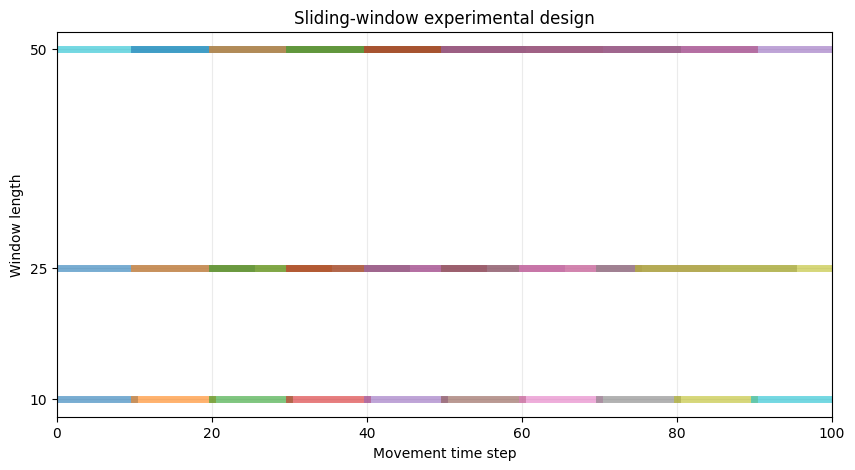

In [6]:
plt.figure(figsize=(10, 5))

for i, row in conditions_df.iterrows():

    plt.plot(
        [row["window_start"], row["window_end"]],
        [row["window_length"], row["window_length"]],
        linewidth=5,
        alpha=0.6,
    )

plt.xlabel("Movement time step")
plt.ylabel("Window length")
plt.title("Sliding-window experimental design")

plt.xlim(0, 100)
plt.yticks(window_sizes)
plt.grid(alpha=0.25)

plt.show()

In [7]:
sliding_results = []

for condition in window_conditions:

    length = condition["window_length"]
    start = condition["window_start"]

    print("\n" + "=" * 65)
    print(
        f"Window length = {length} | "
        f"start = {start} | "
        f"end = {start + length}"
    )
    print("=" * 65)

    config = replace(
        sliding_base_config,
        experiment_name=f"sliding_L{length}_S{start}",
        window_length=length,
        window_start=start,
    )

    result = run_experiment(config)

    sliding_results.append({
        "window_length": length,
        "window_start": start,
        "window_end": start + length,
        "window_center": start + length / 2,
        "result": result,
    })


Window length = 10 | start = 0 | end = 10
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
epoch 01 | train loss 2.0082 | train acc 0.133 | val loss 1.7893 | val acc 0.225
epoch 02 | train loss 1.0622 | train acc 0.592 | val loss 0.2530 | val acc 0.992
epoch 03 | train loss 0.0550 | train acc 0.998 | val loss 0.0084 | val acc 0.996
epoch 04 | train loss 0.0013 | train acc 1.000 | val loss 0.0008 | val acc 1.000
epoch 05 | train loss 0.0003 | train acc 1.000 | val loss 0.0005 | val acc 1.000
epoch 06 | train loss 0.0003 | train acc 1.000 | val loss 0.0005 | val acc 1.000
epoch 07 | train loss 0.0002 | train acc 1.000 | val loss 0.0008 | val acc 1.000
epoch 08 | train loss 0.0002 | train acc 1.000 | val loss 0.0006 | val acc 1.000
epoch 09 | train loss 0.0001 | train acc 1.000 | val loss 0.0005 | val acc 1.000
epoch 10 | train loss 0.0001 | train acc 1.000 | val loss 0.0005 | val acc 1.000
epoch 11 | train loss 0.0001 | trai

In [8]:
sliding_summary = pd.DataFrame({
    "window_length": [
        item["window_length"]
        for item in sliding_results
    ],

    "window_start": [
        item["window_start"]
        for item in sliding_results
    ],

    "window_end": [
        item["window_end"]
        for item in sliding_results
    ],

    "window_center": [
        item["window_center"]
        for item in sliding_results
    ],

    "val_accuracy_most_certain": [
        item["result"]["val_accuracy_most_certain"]
        for item in sliding_results
    ],

    "val_accuracy_final_tick": [
        item["result"]["val_accuracy_final_tick"]
        for item in sliding_results
    ],

    "mean_most_certain_tick": [
        item["result"]["val_mean_most_certain_tick"]
        for item in sliding_results
    ],

    "best_epoch": [
        item["result"]["best_epoch"]
        for item in sliding_results
    ],
})

sliding_summary

,window_length,window_start,window_end,window_center,val_accuracy_most_certain,val_accuracy_final_tick,mean_most_certain_tick,best_epoch
0,10,0,10,5.0,1.0,1.0,25.0,5
1,10,10,20,15.0,1.0,1.0,25.0,15
2,10,20,30,25.0,1.0,1.0,25.0,15
3,10,30,40,35.0,1.0,1.0,25.0,15
4,10,40,50,45.0,1.0,1.0,25.0,15
5,10,50,60,55.0,1.0,1.0,25.0,15
6,10,60,70,65.0,1.0,1.0,25.0,15
7,10,70,80,75.0,1.0,1.0,25.0,15
8,10,80,90,85.0,1.0,1.0,25.0,15
9,10,90,100,95.0,1.0,1.0,25.0,15


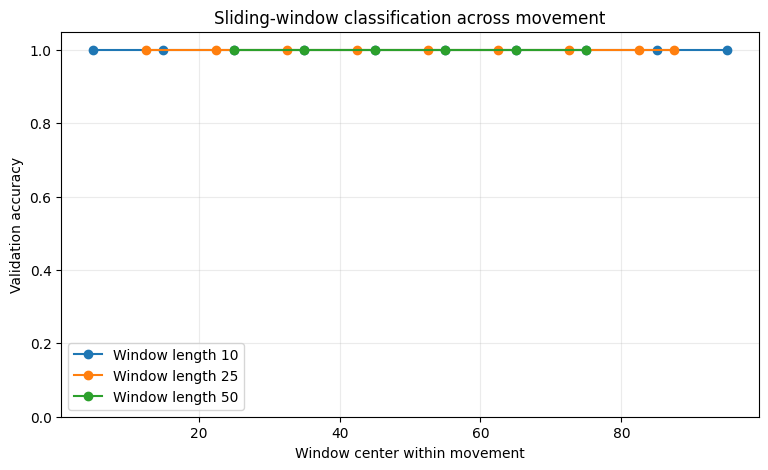

In [9]:
plt.figure(figsize=(9, 5))

for length in window_sizes:

    df = (
        sliding_summary[
            sliding_summary["window_length"] == length
        ]
        .sort_values("window_center")
    )

    plt.plot(
        df["window_center"],
        df["val_accuracy_most_certain"],
        marker="o",
        label=f"Window length {length}",
    )

plt.xlabel("Window center within movement")
plt.ylabel("Validation accuracy")
plt.title("Sliding-window classification across movement")
plt.ylim(0, 1.05)

plt.grid(alpha=0.25)
plt.legend()

plt.show()

In [10]:
sliding_summary["val_loss"] = [
    item["result"]["val_loss"]
    for item in sliding_results
]

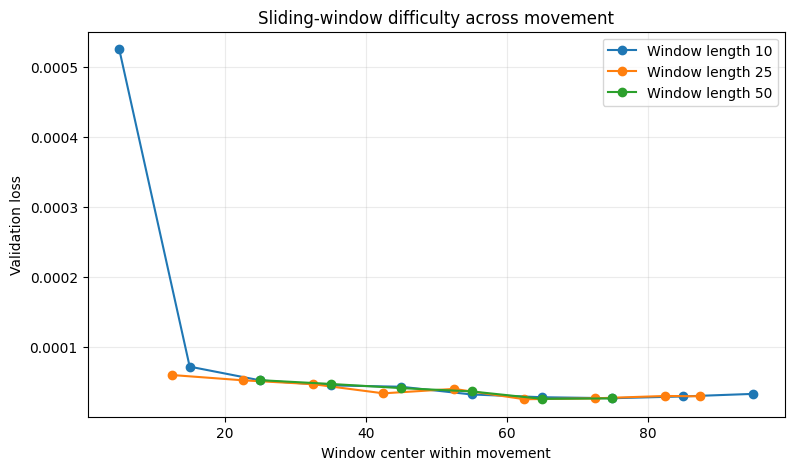

In [11]:
plt.figure(figsize=(9, 5))

for length in window_sizes:

    df = (
        sliding_summary[
            sliding_summary["window_length"] == length
        ]
        .sort_values("window_center")
    )

    plt.plot(
        df["window_center"],
        df["val_loss"],
        marker="o",
        label=f"Window length {length}",
    )

plt.xlabel("Window center within movement")
plt.ylabel("Validation loss")
plt.title("Sliding-window difficulty across movement")
plt.grid(alpha=0.25)
plt.legend()

plt.show()

### Preliminary observation

Classification accuracy remained at 1.000 across all tested sliding
windows, independent of both window size and temporal position.

This includes windows containing only 10 time steps, corresponding to
10% of the complete synthetic trajectory. Moving these short windows
from the beginning to the end of the movement did not reduce eventual
validation accuracy.

Together with the previous prefix-window and fixed-position
experiments, this indicates that the current synthetic trajectories
contain strongly class-separable information throughout the movement.
No specific temporal region appears necessary for successful
classification under the present experimental setup.

The result therefore characterizes an important property of the
synthetic dataset itself: even short local trajectory segments are
sufficient for the CTM to distinguish the target classes.

In [13]:
print("window_results:", "window_results" in globals())
print("sliding_results:", "sliding_results" in globals())
print("tick_results:", "tick_results" in globals())

window_results: False
sliding_results: True
tick_results: False


In [14]:
for length in [10, 25, 50]:
    item = next(
        x for x in sliding_results
        if x["window_length"] == length
    )

    result = item["result"]

    print(
        f"length={length:3d} | "
        f"parameters={result['parameter_count']} | "
        f"effective_timesteps={result['effective_timesteps']}"
    )

length= 10 | parameters=328970 | effective_timesteps=10
length= 25 | parameters=328970 | effective_timesteps=25
length= 50 | parameters=328970 | effective_timesteps=50


In [15]:
result_100 = tick_results[2]["result"]   # 25-tick model, full 100-frame input

print(
    f"length=100 | "
    f"parameters={result_100['parameter_count']} | "
    f"effective_timesteps={result_100['effective_timesteps']}"
)

NameError: name 'tick_results' is not defined

In [16]:
import experiment_runner

[
    name
    for name in dir(experiment_runner)
    if any(
        word in name.lower()
        for word in ["model", "train", "eval", "loader", "experiment"]
    )
]

['DataLoader',
 'ExperimentConfig',
 '__loader__',
 'build_loaders',
 'build_model',
 'evaluate_model',
 'run_experiment']

In [17]:
import inspect

print(inspect.signature(experiment_runner.run_experiment))


(config: 'ExperimentConfig', verbose: 'bool' = True) -> 'dict[str, Any]'


In [18]:
import inspect

print("build_loaders:")
print(inspect.signature(experiment_runner.build_loaders))

print("\nbuild_model:")
print(inspect.signature(experiment_runner.build_model))

print("\nevaluate_model:")
print(inspect.signature(experiment_runner.evaluate_model))

build_loaders:
(config: 'ExperimentConfig') -> 'tuple[DataLoader, DataLoader, DataLoader, dict[str, int]]'

build_model:
(config: 'ExperimentConfig', device: 'torch.device') -> 'ContinuousThoughtMachine'

evaluate_model:
(model: 'ContinuousThoughtMachine', loader: 'DataLoader', device: 'torch.device') -> 'dict[str, float]'


In [19]:
source = inspect.getsource(experiment_runner.run_experiment)
print(source)

def run_experiment(
    config: ExperimentConfig,
    verbose: bool = True,
) -> dict[str, Any]:
    """
    Build, train, validate, and return one traceable result dictionary.
    """
    started_at = time.perf_counter()

    set_run_seed(config.run_seed)
    device = resolve_device(config.device)

    train_loader, val_loader, test_loader, sizes = build_loaders(config)

    model = build_model(config, device)

    # Dry forward pass for LazyLinear initialization.
    dry_X, _ = next(iter(train_loader))
    dry_X = dry_X.to(device)

    # Lazy modules materialize their parameters during this first forward pass.
    # Use no_grad rather than inference_mode so those parameters remain usable
    # by autograd during training.
    with torch.no_grad():
        dry_predictions, dry_certainties, _ = model(dry_X)

    if model.kv_proj[0].in_features != config.n_channels:
        raise RuntimeError(
            "The CTM inferred the wrong feature dimension. "
            f"Expected {config.n_

# Experiment 5: Generalization to Partial Observations

## Question

Can a CTM trained using complete synthetic movements generalize to
incomplete movement observations without retraining?

Previous window experiments showed that partial trajectories contain
sufficient information for classification when a separate model is
trained specifically on each window.

Here, we test a stronger condition. A model is trained using the full
100-step movement and subsequently evaluated using a shorter
observation window.

The primary comparison is:

$$
100 \rightarrow 100
$$

versus

$$
100 \rightarrow 50.
$$

The previously measured $$50 \rightarrow 50$$ condition provides a
matched-window reference.

This experiment therefore distinguishes information availability from
generalization to partial observations.

In [2]:
import torch

from dataclasses import replace

# Full-trajectory training configuration
full_config = ExperimentConfig(
    experiment_name="generalization_full_to_partial",
    data_seed=0,
    split_seed=0,
    run_seed=0,

    noise_std=0.05,
    wiener_sigma=0.0,

    full_timesteps=100,
    window_start=0,
    window_length=None,

    epochs=15,
    evaluate_test=False,
)

# Same data and split, but only first 50 time steps
partial50_config = replace(
    full_config,
    experiment_name="evaluation_first50",
    window_start=0,
    window_length=50,
)

NameError: name 'ExperimentConfig' is not defined

In [21]:
train100_loader, val100_loader, _, sizes100 = (
    experiment_runner.build_loaders(full_config)
)

_, val50_loader, _, sizes50 = (
    experiment_runner.build_loaders(partial50_config)
)

print("Full:", sizes100)
print("Partial:", sizes50)

print(
    "Effective lengths:",
    next(iter(val100_loader))[0].shape[-1],
    next(iter(val50_loader))[0].shape[-1],
)

Full: {'n_train': 1120, 'n_val': 240, 'n_test': 240, 'effective_timesteps': 100}
Partial: {'n_train': 1120, 'n_val': 240, 'n_test': 240, 'effective_timesteps': 50}
Effective lengths: 100 50


In [22]:
experiment_runner.set_run_seed(full_config.run_seed)

device = experiment_runner.resolve_device(full_config.device)

model = experiment_runner.build_model(
    full_config,
    device,
)

# Initialize lazy layers using the 100-step training data
dry_X, _ = next(iter(train100_loader))
dry_X = dry_X.to(device)

with torch.no_grad():
    model(dry_X)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=full_config.learning_rate,
    weight_decay=full_config.weight_decay,
)

print("Device:", device)
print(
    "Parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Device: mps
Parameters: 328970


Existing runner loop, copied faithfully

In [23]:
best_state = None
best_epoch = 0
best_val_accuracy = float("-inf")
best_val_loss = float("inf")

for epoch in range(1, full_config.epochs + 1):

    model.train()

    epoch_loss = 0.0
    epoch_correct = 0
    epoch_seen = 0

    for X_batch, y_batch in train100_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)

        predictions, certainties, _ = model(X_batch)

        loss, idx_max_certainty = experiment_runner.ctm_loss(
            predictions,
            certainties,
            y_batch,
        )

        loss.backward()
        optimizer.step()

        batch_size = y_batch.size(0)

        batch_indices = torch.arange(
            batch_size,
            device=device,
        )

        selected_logits = predictions[
            batch_indices,
            :,
            idx_max_certainty,
        ]

        predicted_classes = selected_logits.argmax(dim=1)

        epoch_loss += loss.item() * batch_size
        epoch_correct += (
            predicted_classes == y_batch
        ).sum().item()

        epoch_seen += batch_size

    validation = experiment_runner.evaluate_model(
        model,
        val100_loader,
        device,
    )

    train_loss = epoch_loss / epoch_seen
    train_accuracy = epoch_correct / epoch_seen

    is_better = (
        validation["accuracy_most_certain"] > best_val_accuracy
        or (
            validation["accuracy_most_certain"]
            == best_val_accuracy
            and validation["loss"] < best_val_loss
        )
    )

    if is_better:
        best_val_accuracy = validation["accuracy_most_certain"]
        best_val_loss = validation["loss"]
        best_epoch = epoch

        best_state = (
            experiment_runner.copy_state_dict_to_cpu(model)
        )

    print(
        f"epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} | "
        f"train acc {train_accuracy:.3f} | "
        f"val loss {validation['loss']:.4f} | "
        f"val acc {validation['accuracy_most_certain']:.3f}"
    )

epoch 01 | train loss 1.7399 | train acc 0.409 | val loss 0.8827 | val acc 1.000
epoch 02 | train loss 0.2261 | train acc 1.000 | val loss 0.0037 | val acc 1.000
epoch 03 | train loss 0.0014 | train acc 1.000 | val loss 0.0006 | val acc 1.000
epoch 04 | train loss 0.0005 | train acc 1.000 | val loss 0.0004 | val acc 1.000
epoch 05 | train loss 0.0003 | train acc 1.000 | val loss 0.0003 | val acc 1.000
epoch 06 | train loss 0.0002 | train acc 1.000 | val loss 0.0002 | val acc 1.000
epoch 07 | train loss 0.0002 | train acc 1.000 | val loss 0.0002 | val acc 1.000
epoch 08 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 09 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 10 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 11 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 12 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 13 | train loss 0.0001

In [24]:
model.load_state_dict(best_state)

print("Best epoch:", best_epoch)

Best epoch: 15


In [25]:
metrics_100 = experiment_runner.evaluate_model(
    model,
    val100_loader,
    device,
)

In [26]:
metrics_50 = experiment_runner.evaluate_model(
    model,
    val50_loader,
    device,
)

In [27]:
generalization_summary = pd.DataFrame({
    "training_length": [100, 100],
    "evaluation_length": [100, 50],

    "accuracy_most_certain": [
        metrics_100["accuracy_most_certain"],
        metrics_50["accuracy_most_certain"],
    ],

    "accuracy_final_tick": [
        metrics_100["accuracy_final_tick"],
        metrics_50["accuracy_final_tick"],
    ],

    "loss": [
        metrics_100["loss"],
        metrics_50["loss"],
    ],

    "mean_most_certain_tick": [
        metrics_100["mean_most_certain_tick"],
        metrics_50["mean_most_certain_tick"],
    ],

    "mean_selected_certainty": [
        metrics_100["mean_selected_certainty"],
        metrics_50["mean_selected_certainty"],
    ],
})

generalization_summary

,training_length,evaluation_length,accuracy_most_certain,accuracy_final_tick,loss,mean_most_certain_tick,mean_selected_certainty
0,100,100,1.0,1.0,0.000045,25.0,0.999752
1,100,50,1.0,1.0,0.002817,25.0,0.991203


### Preliminary observation

The CTM trained exclusively on complete 100-step trajectories retained
perfect validation accuracy when evaluated using only the first 50
steps of the same type of movement, without retraining.

Both the most-certain and final-tick prediction accuracies remained
1.000 under partial observation.

However, partial observation produced a small reduction in predictive
confidence. Validation loss increased from approximately 0.000045 for
the complete trajectory to 0.002817 for the 50-step observation, while
mean selected certainty decreased from approximately 0.9998 to 0.9912.

These results indicate that, within the current synthetic task, the
representation learned from complete trajectories generalizes to an
incomplete observation containing the first half of the movement.
The reduced certainty suggests that some information is lost, even
though this loss is insufficient to change the predicted class.

This result should be interpreted specifically for the first 50% of
the trajectory and the present synthetic data distribution. It does
not yet establish generalization to arbitrarily positioned or much
shorter partial observations.

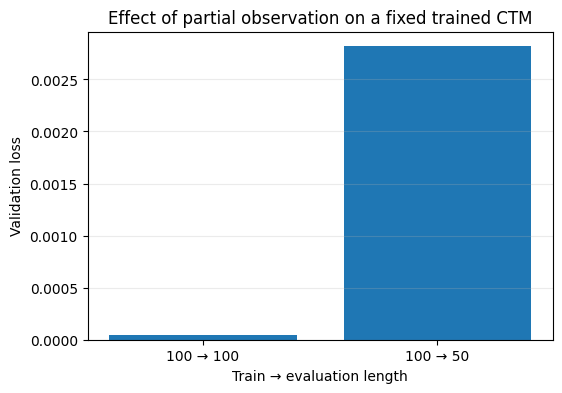

In [28]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["100 → 100", "100 → 50"],
    generalization_summary["loss"],
)

plt.ylabel("Validation loss")
plt.xlabel("Train → evaluation length")
plt.title("Effect of partial observation on a fixed trained CTM")
plt.grid(axis="y", alpha=0.25)

plt.show()

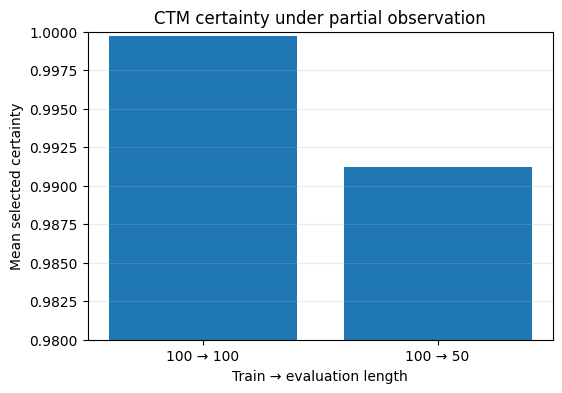

In [29]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["100 → 100", "100 → 50"],
    generalization_summary["mean_selected_certainty"],
)

plt.ylabel("Mean selected certainty")
plt.xlabel("Train → evaluation length")
plt.title("CTM certainty under partial observation")
plt.ylim(0.98, 1.0)
plt.grid(axis="y", alpha=0.25)

plt.show()

# Experiment 6: Generalization Across Observation Length

## Question

How does a CTM trained exclusively on complete 100-step trajectories
perform when progressively less of the movement is available at
evaluation time?

A single CTM is trained using the full 100-step synthetic trajectories.
The trained model is then kept fixed and evaluated, without retraining,
on movement prefixes of length

$$
T_{\mathrm{obs}} \in \{100, 75, 50, 25, 10\}.
$$

All partial observations begin at movement onset. Therefore, this
experiment varies the amount of available evidence while keeping the
trained model, data generation, data split, and temporal starting
position fixed.

This differs from the earlier window-length experiment, where a
separate model was trained for each observation length. Here the aim is
to measure generalization of a full-trajectory model to progressively
incomplete observations.

In [6]:
import importlib
import torch
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import replace

import experiment_runner
importlib.reload(experiment_runner)

from experiment_runner import ExperimentConfig

print("Experiment 6 setup ready.")

Experiment 6 setup ready.


/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
full_config = ExperimentConfig(
    experiment_name="generalization_length_sweep",

    data_seed=0,
    split_seed=0,
    run_seed=0,

    noise_std=0.05,
    wiener_sigma=0.0,

    full_timesteps=100,
    window_start=0,
    window_length=None,

    epochs=15,
    evaluate_test=False,
)

full_config

ExperimentConfig(experiment_name='generalization_length_sweep', data_seed=0, split_seed=0, run_seed=0, n_per_class=200, n_classes=8, n_channels=15, full_timesteps=100, noise_std=0.05, wiener_sigma=0.0, window_start=0, window_length=None, train_fraction=0.7, val_fraction=0.15, batch_size=32, iterations=25, d_model=256, d_input=64, heads=4, n_synch_out=32, n_synch_action=32, synapse_depth=1, memory_length=15, deep_nlms=True, memory_hidden_dims=16, do_layernorm_nlm=False, dropout=0.0, neuron_select_type='random-pairing', n_random_pairing_self=0, learning_rate=0.0003, weight_decay=0.0, epochs=15, device='auto', evaluate_test=False)

Building the 100-step training data

In [10]:
experiment_runner.set_run_seed(full_config.run_seed)

train100_loader, val100_loader, _, sizes100 = (
    experiment_runner.build_loaders(full_config)
)

X_batch, y_batch = next(iter(train100_loader))

print("Training input shape:", X_batch.shape)
print("Training set size:", sizes100["n_train"])
print("Validation set size:", sizes100["n_val"])
print("Effective timesteps:", X_batch.shape[-1])

Training input shape: torch.Size([32, 15, 100])
Training set size: 1120
Validation set size: 240
Effective timesteps: 100


Building One CTM

In [11]:
device = experiment_runner.resolve_device(full_config.device)

model = experiment_runner.build_model(
    full_config,
    device,
)

# Initialize LazyLinear layers
dry_X, _ = next(iter(train100_loader))
dry_X = dry_X.to(device)

with torch.no_grad():
    model(dry_X)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=full_config.learning_rate,
    weight_decay=full_config.weight_decay,
)

parameter_count = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Device:", device)
print("Parameters:", parameter_count)

Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Device: mps
Parameters: 328970


Training that model only on 100-step trajectories

In [12]:
best_state = None
best_epoch = 0

best_val_accuracy = float("-inf")
best_val_loss = float("inf")

for epoch in range(1, full_config.epochs + 1):

    model.train()

    epoch_loss = 0.0
    epoch_correct = 0
    epoch_seen = 0

    for X_batch, y_batch in train100_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)

        predictions, certainties, _ = model(X_batch)

        loss, idx_max_certainty = experiment_runner.ctm_loss(
            predictions,
            certainties,
            y_batch,
        )

        loss.backward()
        optimizer.step()

        batch_size = y_batch.size(0)

        batch_indices = torch.arange(
            batch_size,
            device=device,
        )

        selected_logits = predictions[
            batch_indices,
            :,
            idx_max_certainty,
        ]

        predicted_classes = selected_logits.argmax(dim=1)

        epoch_loss += loss.item() * batch_size

        epoch_correct += (
            predicted_classes == y_batch
        ).sum().item()

        epoch_seen += batch_size

    validation = experiment_runner.evaluate_model(
        model,
        val100_loader,
        device,
    )

    train_loss = epoch_loss / epoch_seen
    train_accuracy = epoch_correct / epoch_seen

    is_better = (
        validation["accuracy_most_certain"] > best_val_accuracy
        or (
            validation["accuracy_most_certain"]
            == best_val_accuracy
            and validation["loss"] < best_val_loss
        )
    )

    if is_better:

        best_val_accuracy = validation["accuracy_most_certain"]
        best_val_loss = validation["loss"]
        best_epoch = epoch

        best_state = (
            experiment_runner.copy_state_dict_to_cpu(model)
        )

    print(
        f"epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} | "
        f"train acc {train_accuracy:.3f} | "
        f"val loss {validation['loss']:.4f} | "
        f"val acc {validation['accuracy_most_certain']:.3f}"
    )


# Restore the best 100-step-trained model
model.load_state_dict(best_state)

print("\nBest epoch:", best_epoch)
print("Training complete. Model will NOT be retrained.")

epoch 01 | train loss 1.7418 | train acc 0.387 | val loss 0.8829 | val acc 1.000
epoch 02 | train loss 0.2327 | train acc 1.000 | val loss 0.0030 | val acc 1.000
epoch 03 | train loss 0.0012 | train acc 1.000 | val loss 0.0006 | val acc 1.000
epoch 04 | train loss 0.0005 | train acc 1.000 | val loss 0.0004 | val acc 1.000
epoch 05 | train loss 0.0003 | train acc 1.000 | val loss 0.0003 | val acc 1.000
epoch 06 | train loss 0.0002 | train acc 1.000 | val loss 0.0002 | val acc 1.000
epoch 07 | train loss 0.0002 | train acc 1.000 | val loss 0.0002 | val acc 1.000
epoch 08 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 09 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 10 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 11 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 12 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 13 | train loss 0.0001

creating five evaluation conditions

In [13]:
observation_lengths = [100, 75, 50, 25, 10]

evaluation_loaders = {}

for length in observation_lengths:

    if length == 100:

        eval_config = replace(
            full_config,
            experiment_name="eval_T100",
            window_start=0,
            window_length=None,
        )

    else:

        eval_config = replace(
            full_config,
            experiment_name=f"eval_T{length}",
            window_start=0,
            window_length=length,
        )

    _, val_loader, _, sizes = (
        experiment_runner.build_loaders(eval_config)
    )

    evaluation_loaders[length] = val_loader

    X_eval, _ = next(iter(val_loader))

    print(
        f"T_obs={length:3d} | "
        f"input length={X_eval.shape[-1]:3d} | "
        f"n_val={sizes['n_val']}"
    )

T_obs=100 | input length=100 | n_val=240
T_obs= 75 | input length= 75 | n_val=240
T_obs= 50 | input length= 50 | n_val=240
T_obs= 25 | input length= 25 | n_val=240
T_obs= 10 | input length= 10 | n_val=240


Performing the actual generalization experiment (no training happens here)

In [14]:
length_generalization_results = []

for length in observation_lengths:

    metrics = experiment_runner.evaluate_model(
        model,
        evaluation_loaders[length],
        device,
    )

    length_generalization_results.append({
        "evaluation_length": length,
        "fraction_observed": length / 100,

        "accuracy_most_certain":
            metrics["accuracy_most_certain"],

        "accuracy_final_tick":
            metrics["accuracy_final_tick"],

        "loss":
            metrics["loss"],

        "mean_most_certain_tick":
            metrics["mean_most_certain_tick"],

        "mean_selected_certainty":
            metrics["mean_selected_certainty"],
    })


length_generalization_summary = pd.DataFrame(
    length_generalization_results
)

length_generalization_summary

,evaluation_length,fraction_observed,accuracy_most_certain,accuracy_final_tick,loss,mean_most_certain_tick,mean_selected_certainty
0,100,1.00,1.000000,1.000000,0.000047,25.000000,0.999741
1,75,0.75,1.000000,1.000000,0.000075,25.000000,0.999609
2,50,0.50,1.000000,1.000000,0.001452,25.000000,0.994847
3,25,0.25,0.625000,0.625000,0.994677,25.000000,0.820388
4,10,0.10,0.245833,0.245833,2.833915,24.995833,0.654492


### How CTM certainty is calculated

The CTM produces a class prediction at every internal tick. For an
8-class problem, the logits at internal tick \(t\) are converted to
class probabilities using softmax:

$$
p_{c,t}
=
\operatorname{softmax}(y_t)_c.
$$

The uncertainty of this prediction is measured using entropy:

$$
H_t
=
-\sum_{c=1}^{C}
p_{c,t}\log p_{c,t}.
$$

For \(C\) classes, the maximum possible entropy is

$$
H_{\max}
=
\log C.
$$

The CTM normalizes the entropy and defines certainty as

$$
C_t
=
1-\frac{H_t}{\log C}.
$$

Therefore,

$$
0 \leq C_t \leq 1.
$$

A certainty close to 0 corresponds to a high-entropy prediction in
which probability is distributed relatively evenly across classes.

A certainty close to 1 corresponds to a low-entropy prediction in
which probability is concentrated strongly on one or a few classes.

For the current experiments,

$$
C=8.
$$

The reported `mean_selected_certainty` is obtained by first selecting,
for each validation sample, the internal tick with the highest
certainty and then averaging those selected certainty values across
the validation set.

Thus, a value such as

$$
0.654
$$

does **not** mean that the model has a 65.4% probability of being
correct. It is an entropy-derived measure of how concentrated the
model's class prediction is.

In Experiment 6, reducing the available movement from 100 to 10 time
steps lowered the mean selected certainty from approximately 1.0 to
0.654, while classification accuracy also dropped substantially. This
shows that the shortened input affected both prediction correctness
and the concentration of the model's output distribution.

#### does classification survive shorter observations?

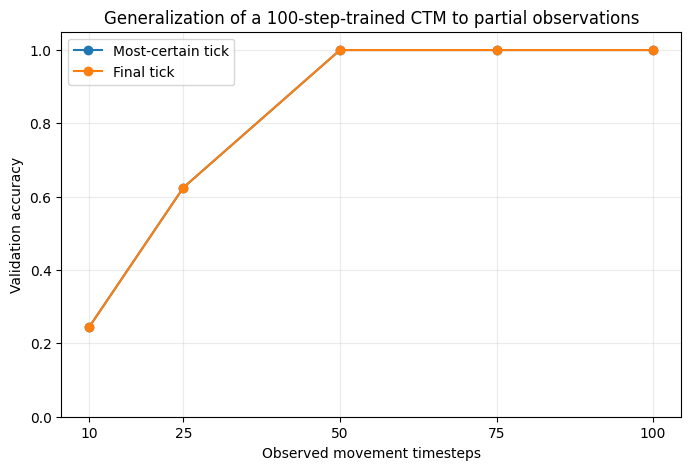

In [15]:
plot_df = (
    length_generalization_summary
    .sort_values("evaluation_length")
)

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["evaluation_length"],
    plot_df["accuracy_most_certain"],
    marker="o",
    label="Most-certain tick",
)

plt.plot(
    plot_df["evaluation_length"],
    plot_df["accuracy_final_tick"],
    marker="o",
    label="Final tick",
)

plt.xlabel("Observed movement timesteps")
plt.ylabel("Validation accuracy")

plt.title(
    "Generalization of a 100-step-trained CTM "
    "to partial observations"
)

plt.xticks([10, 25, 50, 75, 100])
plt.ylim(0, 1.05)

plt.grid(alpha=0.25)
plt.legend()

plt.show()

Second plot: certainty

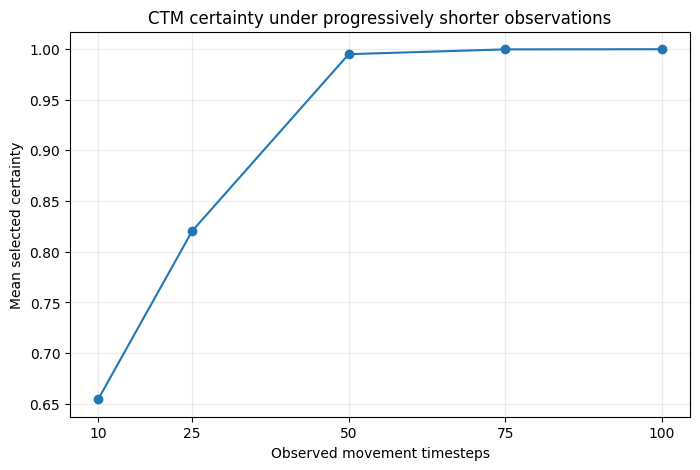

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["evaluation_length"],
    plot_df["mean_selected_certainty"],
    marker="o",
)

plt.xlabel("Observed movement timesteps")
plt.ylabel("Mean selected certainty")

plt.title(
    "CTM certainty under progressively "
    "shorter observations"
)

plt.xticks([10, 25, 50, 75, 100])

plt.grid(alpha=0.25)

plt.show()

Validation Loss

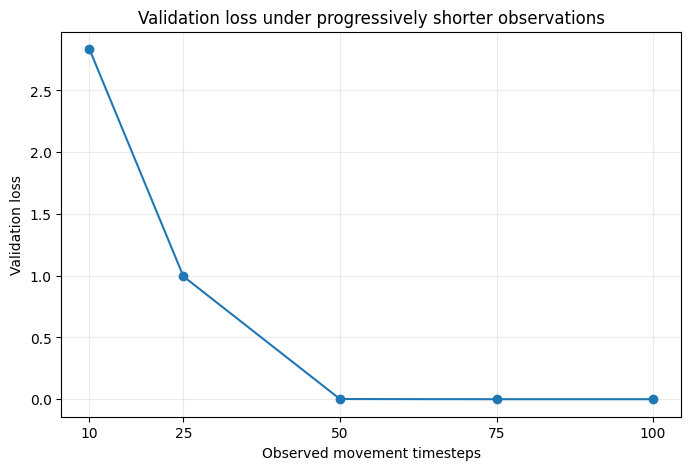

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["evaluation_length"],
    plot_df["loss"],
    marker="o",
)

plt.xlabel("Observed movement timesteps")
plt.ylabel("Validation loss")

plt.title(
    "Validation loss under progressively "
    "shorter observations"
)

plt.xticks([10, 25, 50, 75, 100])

plt.grid(alpha=0.25)

plt.show()

### Preliminary observation

The CTM trained exclusively on complete 100-step trajectories
generalized successfully when moderate amounts of the movement were
removed. Validation accuracy remained 1.000 when the available
observation was reduced from 100 to 75 and 50 time steps.

Performance deteriorated substantially for shorter observations.
Using only the first 25 time steps reduced validation accuracy to
0.625, while using only the first 10 time steps reduced accuracy to
approximately 0.246.

The degradation was also reflected in the model's confidence.
Mean selected certainty decreased from approximately 1.00 for
50--100-step observations to 0.82 at 25 steps and 0.65 at 10 steps.
Validation loss increased correspondingly.

This result is particularly informative when compared with the
earlier window-length experiments. Models trained specifically on
10- and 25-step trajectory prefixes were able to achieve perfect
classification. Therefore, the reduced performance observed here
cannot be attributed simply to an absence of class-discriminative
information in these early movement segments.

Instead, the result indicates that a representation learned from
complete trajectories does not fully generalize to severely truncated
observations, even though those observations themselves contain
sufficient information when the model is trained for them.

Within the tested conditions, the transition occurs between 25 and
50 observed time steps. A denser sweep would be required to identify
a more precise transition point.

The mean most-certain internal tick remained approximately 25 for all
observation lengths, suggesting that increasing internal computation
within the current computational budget does not compensate for the
distribution shift introduced by strongly shortened external
observations.

# Experiment 7: Joint Effect of Wiener Noise, Window Size, and Window Position

## Question

How do window size and temporal position interact with temporally
correlated Wiener noise?

Previous experiments studied Wiener noise and trajectory windows
separately.

The Wiener-noise experiment showed that weak correlated perturbations
had little effect on classification, while stronger Wiener drift
substantially reduced performance.

The window experiments showed that, in the absence of Wiener noise,
short local trajectory segments remained highly discriminative across
many temporal positions.

The present experiment combines these factors.

We vary:

1. window size,
2. window position,
3. Wiener-noise level.

To avoid redundancy between highly overlapping windows, the shorter
windows are placed so that they tile the 100-step trajectory without
overlap.

The window configurations are:

$$
L=100:
\quad
s=\{0\}
$$

$$
L=75:
\quad
s=\{0\}
$$

$$
L=50:
\quad
s=\{0,50\}
$$

$$
L=25:
\quad
s=\{0,25,50,75\}
$$

$$
L=10:
\quad
s=\{0,10,20,30,40,50,60,70,80,90\}.
$$

This gives

$$
1+1+2+4+10=18
$$

window conditions.

Each condition is evaluated under two Wiener-noise settings:

$$
\sigma_W \in \{0.0,1.0\}.
$$

Therefore the full design contains

$$
18 \times 2 = 36
$$

training conditions.

The clean condition,

$$
\sigma_W=0.0,
$$

provides a reference for the effect of window size and position without
temporally correlated perturbation.

The noisy condition,

$$
\sigma_W=1.0,
$$

was selected based on the earlier Wiener-noise sweep. Values of
0.1 and 0.5 produced little degradation, while 1.0 caused a clear but
non-catastrophic decrease in performance. A stronger value of 2.0
reduced performance substantially and could obscure differences caused
by window size and position.

For each of the 36 conditions, a separate CTM is trained and validated
using the corresponding window and Wiener-noise level.

Therefore this experiment measures learnability under the joint
combination of temporal corruption and restricted trajectory evidence.
It is not a fixed-model robustness experiment.

In [18]:
window_conditions = []

# Full / long controls
window_conditions.append((100, 0))
window_conditions.append((75, 0))

# Non-overlapping windows
for start in [0, 50]:
    window_conditions.append((50, start))

for start in [0, 25, 50, 75]:
    window_conditions.append((25, start))

for start in range(0, 100, 10):
    window_conditions.append((10, start))

print("Number of window conditions:", len(window_conditions))
print(window_conditions)

Number of window conditions: 18
[(100, 0), (75, 0), (50, 0), (50, 50), (25, 0), (25, 25), (25, 50), (25, 75), (10, 0), (10, 10), (10, 20), (10, 30), (10, 40), (10, 50), (10, 60), (10, 70), (10, 80), (10, 90)]


In [19]:
wiener_levels = [0.0, 1.0]

print(
    "Total experiment conditions:",
    len(window_conditions) * len(wiener_levels)
)

Total experiment conditions: 36


In [20]:
design_rows = []

for sigma in wiener_levels:
    for length, start in window_conditions:
        design_rows.append({
            "wiener_sigma": sigma,
            "window_length": length,
            "window_start": start,
            "window_end": start + length,
            "window_center": start + length / 2,
        })

final_design = pd.DataFrame(design_rows)

final_design

,wiener_sigma,window_length,window_start,window_end,window_center
0,0.0,100,0,100,50.0
1,0.0,75,0,75,37.5
2,0.0,50,0,50,25.0
3,0.0,50,50,100,75.0
4,0.0,25,0,25,12.5
5,0.0,25,25,50,37.5
6,0.0,25,50,75,62.5
7,0.0,25,75,100,87.5
8,0.0,10,0,10,5.0
9,0.0,10,10,20,15.0


In [21]:
from dataclasses import replace
from experiment_runner import ExperimentConfig, run_experiment

joint_base_config = ExperimentConfig(
    experiment_name="joint_window_wiener",

    data_seed=0,
    split_seed=0,
    run_seed=0,

    # Keep the ordinary synthetic noise fixed.
    noise_std=0.05,

    # Overwritten below for each condition.
    wiener_sigma=0.0,

    full_timesteps=100,
    window_start=0,
    window_length=None,

    epochs=15,
    evaluate_test=False,
)

joint_base_config

ExperimentConfig(experiment_name='joint_window_wiener', data_seed=0, split_seed=0, run_seed=0, n_per_class=200, n_classes=8, n_channels=15, full_timesteps=100, noise_std=0.05, wiener_sigma=0.0, window_start=0, window_length=None, train_fraction=0.7, val_fraction=0.15, batch_size=32, iterations=25, d_model=256, d_input=64, heads=4, n_synch_out=32, n_synch_action=32, synapse_depth=1, memory_length=15, deep_nlms=True, memory_hidden_dims=16, do_layernorm_nlm=False, dropout=0.0, neuron_select_type='random-pairing', n_random_pairing_self=0, learning_rate=0.0003, weight_decay=0.0, epochs=15, device='auto', evaluate_test=False)

In [22]:
joint_results = []

for sigma in wiener_levels:

    for length, start in window_conditions:

        print("\n" + "=" * 75)
        print(
            f"Wiener sigma = {sigma} | "
            f"window length = {length} | "
            f"start = {start} | "
            f"end = {start + length}"
        )
        print("=" * 75)

        config = replace(
            joint_base_config,

            experiment_name=(
                f"joint_wiener{sigma}_"
                f"L{length}_S{start}"
            ),

            wiener_sigma=sigma,
            window_length=length,
            window_start=start,
        )

        result = run_experiment(config)

        joint_results.append({
            "wiener_sigma": sigma,
            "window_length": length,
            "window_start": start,
            "window_end": start + length,
            "window_center": start + length / 2,
            "result": result,
        })


Wiener sigma = 0.0 | window length = 100 | start = 0 | end = 100
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
epoch 01 | train loss 1.7399 | train acc 0.409 | val loss 0.8827 | val acc 1.000
epoch 02 | train loss 0.2261 | train acc 1.000 | val loss 0.0037 | val acc 1.000
epoch 03 | train loss 0.0014 | train acc 1.000 | val loss 0.0006 | val acc 1.000
epoch 04 | train loss 0.0005 | train acc 1.000 | val loss 0.0004 | val acc 1.000
epoch 05 | train loss 0.0003 | train acc 1.000 | val loss 0.0003 | val acc 1.000
epoch 06 | train loss 0.0002 | train acc 1.000 | val loss 0.0002 | val acc 1.000
epoch 07 | train loss 0.0002 | train acc 1.000 | val loss 0.0002 | val acc 1.000
epoch 08 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 09 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 10 | train loss 0.0001 | train acc 1.000 | val loss 0.0001 | val acc 1.000
epoch 11 | t

In [23]:
joint_summary = pd.DataFrame({
    "wiener_sigma": [
        item["wiener_sigma"]
        for item in joint_results
    ],

    "window_length": [
        item["window_length"]
        for item in joint_results
    ],

    "window_start": [
        item["window_start"]
        for item in joint_results
    ],

    "window_end": [
        item["window_end"]
        for item in joint_results
    ],

    "window_center": [
        item["window_center"]
        for item in joint_results
    ],

    "val_accuracy": [
        item["result"]["val_accuracy_most_certain"]
        for item in joint_results
    ],

    "val_accuracy_final_tick": [
        item["result"]["val_accuracy_final_tick"]
        for item in joint_results
    ],

    "val_loss": [
        item["result"]["val_loss"]
        for item in joint_results
    ],

    "mean_certainty": [
        item["result"]["val_mean_selected_certainty"]
        for item in joint_results
    ],

    "mean_most_certain_tick": [
        item["result"]["val_mean_most_certain_tick"]
        for item in joint_results
    ],

    "best_epoch": [
        item["result"]["best_epoch"]
        for item in joint_results
    ],
})

joint_summary

,wiener_sigma,window_length,window_start,window_end,window_center,val_accuracy,val_accuracy_final_tick,val_loss,mean_certainty,mean_most_certain_tick,best_epoch
0,0.0,100,0,100,50.0,1.000000,1.000000,0.000045,0.999752,25.000000,15
1,0.0,75,0,75,37.5,1.000000,1.000000,0.000049,0.999726,25.000000,15
2,0.0,50,0,50,25.0,1.000000,1.000000,0.000053,0.999704,25.000000,15
3,0.0,50,50,100,75.0,1.000000,1.000000,0.000027,0.999839,25.000000,15
4,0.0,25,0,25,12.5,1.000000,1.000000,0.000060,0.999677,25.000000,15
5,0.0,25,25,50,37.5,1.000000,1.000000,0.000047,0.999740,25.000000,15
6,0.0,25,50,75,62.5,1.000000,1.000000,0.000026,0.999847,25.000000,15
7,0.0,25,75,100,87.5,1.000000,1.000000,0.000030,0.999830,25.000000,15
8,0.0,10,0,10,5.0,1.000000,1.000000,0.000525,0.998575,25.000000,5
9,0.0,10,10,20,15.0,1.000000,1.000000,0.000072,0.999622,25.000000,15


In [24]:
print("Rows:", len(joint_summary))

print(
    joint_summary
    .groupby("wiener_sigma")
    .size()
)

Rows: 36
wiener_sigma
0.0    18
1.0    18
dtype: int64


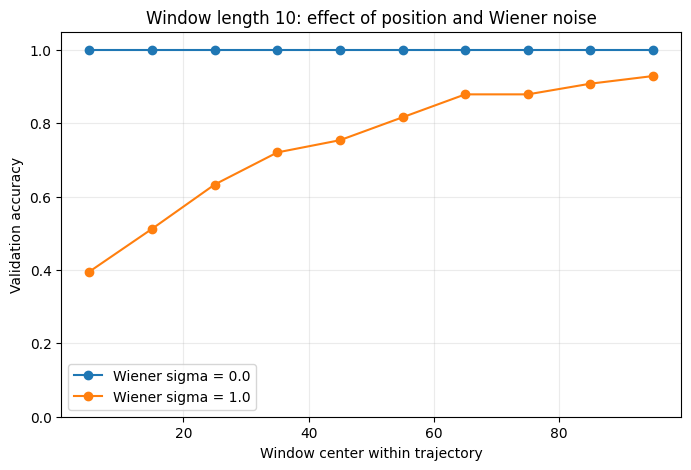

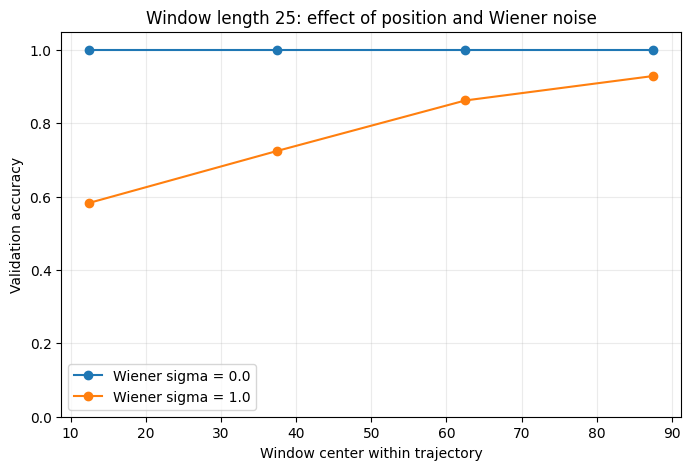

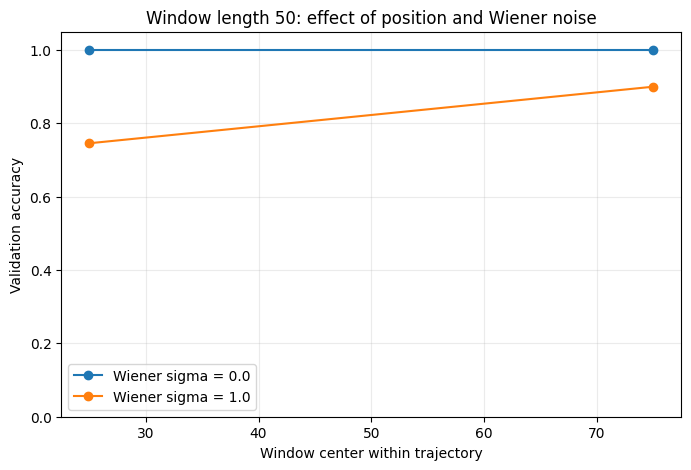

In [25]:
for length in [10, 25, 50]:

    plt.figure(figsize=(8, 5))

    for sigma in wiener_levels:

        df = (
            joint_summary[
                (joint_summary["window_length"] == length)
                &
                (joint_summary["wiener_sigma"] == sigma)
            ]
            .sort_values("window_center")
        )

        plt.plot(
            df["window_center"],
            df["val_accuracy"],
            marker="o",
            label=f"Wiener sigma = {sigma}",
        )

    plt.xlabel("Window center within trajectory")
    plt.ylabel("Validation accuracy")

    plt.title(
        f"Window length {length}: "
        "effect of position and Wiener noise"
    )

    plt.ylim(0, 1.05)
    plt.grid(alpha=0.25)
    plt.legend()

    plt.show()

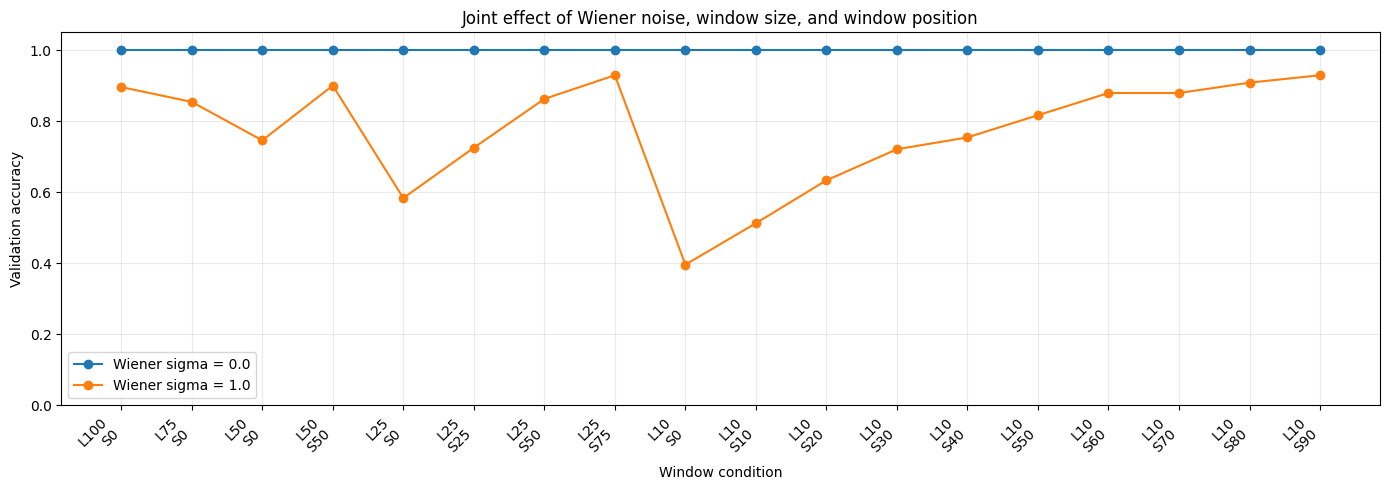

In [26]:
plot_order = (
    joint_summary[
        joint_summary["wiener_sigma"] == 0.0
    ][
        ["window_length", "window_start"]
    ]
    .reset_index(drop=True)
)

labels = [
    f"L{int(row.window_length)}\nS{int(row.window_start)}"
    for _, row in plot_order.iterrows()
]

plt.figure(figsize=(14, 5))

for sigma in wiener_levels:

    df = (
        joint_summary[
            joint_summary["wiener_sigma"] == sigma
        ]
        .set_index(["window_length", "window_start"])
        .loc[
            list(
                zip(
                    plot_order["window_length"],
                    plot_order["window_start"],
                )
            )
        ]
        .reset_index()
    )

    plt.plot(
        range(len(df)),
        df["val_accuracy"],
        marker="o",
        label=f"Wiener sigma = {sigma}",
    )

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right",
)

plt.ylabel("Validation accuracy")
plt.xlabel("Window condition")

plt.title(
    "Joint effect of Wiener noise, "
    "window size, and window position"
)

plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

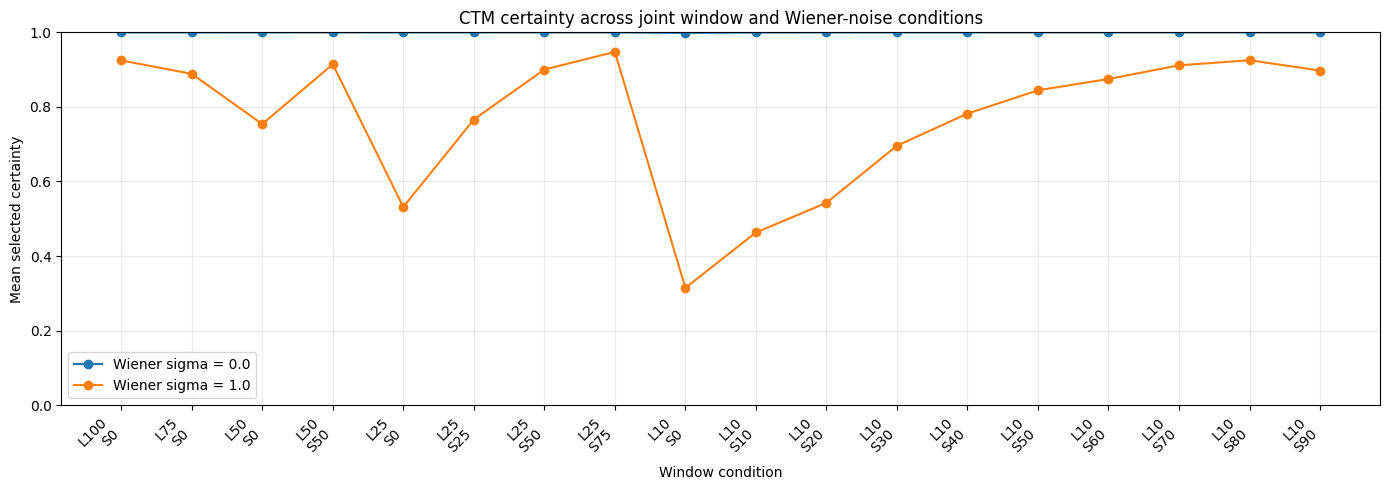

In [27]:
plt.figure(figsize=(14, 5))

for sigma in wiener_levels:

    df = (
        joint_summary[
            joint_summary["wiener_sigma"] == sigma
        ]
        .set_index(["window_length", "window_start"])
        .loc[
            list(
                zip(
                    plot_order["window_length"],
                    plot_order["window_start"],
                )
            )
        ]
        .reset_index()
    )

    plt.plot(
        range(len(df)),
        df["mean_certainty"],
        marker="o",
        label=f"Wiener sigma = {sigma}",
    )

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right",
)

plt.ylabel("Mean selected certainty")
plt.xlabel("Window condition")

plt.title(
    "CTM certainty across joint "
    "window and Wiener-noise conditions"
)

plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

### Noise-control clarification

The condition

$$
\sigma_W = 0.0
$$

should be interpreted as the **Wiener-free control**, rather than as
a completely noiseless trajectory.

The original synthetic-data generator still uses the fixed baseline
independent Gaussian noise level

$$
\sigma_{\mathrm{IID}} = 0.05
$$

for all conditions.

Therefore the only noise factor changed in this experiment is the
additional temporally correlated Wiener perturbation. This keeps the
comparison consistent with the previous window experiments.

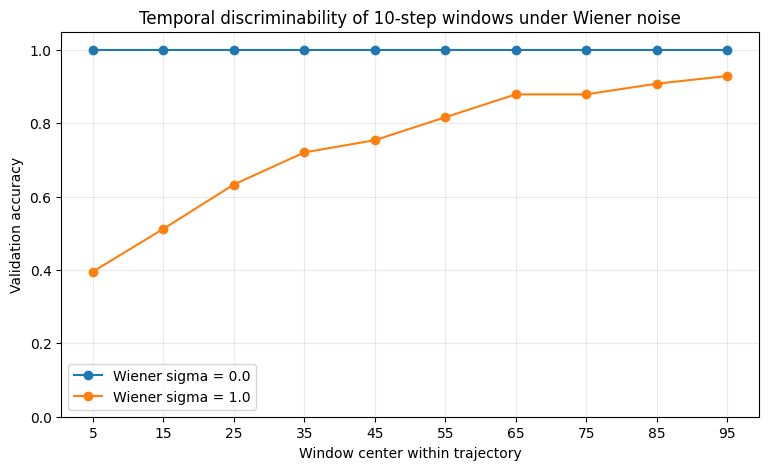

In [29]:
noisy_10 = (
    joint_summary[
        (joint_summary["window_length"] == 10)
    ]
    .sort_values(["wiener_sigma", "window_start"])
)

plt.figure(figsize=(9, 5))

for sigma in [0.0, 1.0]:

    df = noisy_10[
        noisy_10["wiener_sigma"] == sigma
    ]

    plt.plot(
        df["window_center"],
        df["val_accuracy"],
        marker="o",
        label=f"Wiener sigma = {sigma}",
    )

plt.xlabel("Window center within trajectory")
plt.ylabel("Validation accuracy")

plt.title(
    "Temporal discriminability of 10-step windows "
    "under Wiener noise"
)

plt.xticks(range(5, 100, 10))
plt.ylim(0, 1.05)

plt.grid(alpha=0.25)
plt.legend()

plt.show()

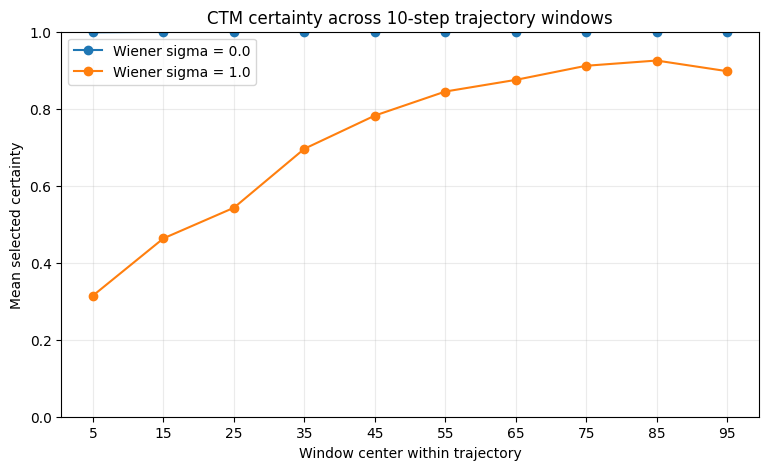

In [30]:
plt.figure(figsize=(9, 5))

for sigma in [0.0, 1.0]:

    df = (
        joint_summary[
            (joint_summary["window_length"] == 10)
            &
            (joint_summary["wiener_sigma"] == sigma)
        ]
        .sort_values("window_center")
    )

    plt.plot(
        df["window_center"],
        df["mean_certainty"],
        marker="o",
        label=f"Wiener sigma = {sigma}",
    )

plt.xlabel("Window center within trajectory")
plt.ylabel("Mean selected certainty")

plt.title(
    "CTM certainty across 10-step trajectory windows"
)

plt.xticks(range(5, 100, 10))
plt.ylim(0, 1)

plt.grid(alpha=0.25)
plt.legend()

plt.show()

In [31]:
noisy_summary = (
    joint_summary[
        joint_summary["wiener_sigma"] == 1.0
    ]
    .groupby("window_length")
    ["val_accuracy"]
    .agg(["mean", "min", "max"])
    .reset_index()
    .sort_values("window_length")
)

noisy_summary

,window_length,mean,min,max
0,10,0.742917,0.395833,0.929167
1,25,0.775000,0.583333,0.929167
2,50,0.822917,0.745833,0.900000
3,75,0.854167,0.854167,0.854167
4,100,0.895833,0.895833,0.895833


### Results and interpretation

Under the Wiener-free control condition, validation accuracy remained
1.000 for all 18 window configurations. Consequently, window size and
window position could not be distinguished using classification
accuracy alone under the baseline synthetic conditions.

Introducing temporally correlated Wiener noise with

$$
\sigma_W = 1.0
$$

removed this ceiling effect and revealed a strong interaction between
trajectory position and classification performance.

For 25-step windows, validation accuracy increased systematically from

$$
0.583
$$

for the first quarter of the trajectory to

$$
0.929
$$

for the final quarter.

An even clearer temporal progression was observed for the 10-step
windows. Accuracy increased from approximately

$$
0.396
$$

for the interval 0-10 to

$$
0.929
$$

for the interval 90-100.

The same effect was visible for 50-step windows: the first half of the
trajectory produced an accuracy of approximately 0.746, whereas the
second half reached 0.900.

Mean selected certainty showed a corresponding temporal trend. For
10-step windows under Wiener noise, certainty was lowest for the
earliest trajectory segments and generally increased toward later
segments.

These results indicate that the synthetic trajectories do not contain
equally robust class information throughout the movement. Under weak
baseline perturbation this structure is hidden by saturated
classification performance. Temporally correlated noise exposes it:
later trajectory segments remain substantially more discriminative
than early segments.

This result is notable because Wiener perturbations accumulate over
time. Despite this increasing temporal corruption, classification
performance improves for later windows. A likely explanation is that
class-specific trajectory separation also increases during movement,
and the growing discriminative signal dominates the accumulated noise.

Therefore, Wiener noise acts not only as a robustness perturbation but
also as a useful stress test for revealing where class-discriminative
information becomes sufficiently strong along the synthetic
trajectory.

The experiment demonstrates an interaction between:

$$
\text{Wiener noise level}
\times
\text{window size}
\times
\text{window position}.
$$

Because each condition was trained separately, these results describe
the learnability of individual trajectory regions under correlated
noise. They should not be interpreted as fixed-model generalization
across windows.